# Mission Health — Early Risk Prediction of Type-2 Diabetes in Under-Resourced Clinics
### CIA-3 Machine Learning: ML for Social Good Challenge

**Author:** Maniarasan J (2547261)
**Course:** MCA 521-4 — Machine Learning
**Mission selected:** Mission Health



## Q1. Real-World Impact Framing (5 marks)

### The problem
Type-2 diabetes and pre-diabetes are largely preventable and manageable non-communicable diseases (NCDs), but in under-resourced primary-health clinics, diagnosis often relies on expensive lab tests (e.g. fasting glucose, HbA1c) or happens too late, after complications appear. A low-cost triage tool that flags **early risk** using cheap, routinely-collected measurements (age, BMI, blood pressure, pregnancy history, family history proxy) can help frontline health workers prioritise patients for confirmatory testing and lifestyle counselling.

### Intended beneficiaries
- **Primary beneficiaries:** Women attending under-resourced maternal/primary-care clinics who are screened for diabetes risk during routine visits.
- **Secondary beneficiaries:** Clinic staff / community health workers (CHWs) who get a cheap decision-support signal; public-health systems that can allocate scarce lab-testing capacity more efficiently.

### Prediction target
Binary classification: **`Outcome`** — whether a patient tests positive for diabetes (1) or not (0), based on the Pima Indians Diabetes dataset's clinically diagnosed outcome variable.

### Measurable impact
- **Screening efficiency:** Recall (sensitivity) on the positive class — how many at-risk patients the model successfully flags for confirmatory testing, since missing a true diabetic (false negative) is the costlier error in this domain.
- **Resource savings:** Reduction in unnecessary lab tests for very-low-risk patients (precision), freeing up scarce diagnostic capacity.
- **Equity proxy:** Consistent recall across BMI/age sub-groups so the tool does not systematically under-flag any sub-population.

### Why Machine Learning is suitable
- The relationship between routinely measured variables (glucose, BMI, age, pregnancies, blood pressure, skin-fold thickness, insulin, pedigree function) and diabetes risk is **non-linear and involves interactions** (e.g. BMI × age, glucose × insulin) that simple rule-based clinical heuristics do not capture well.
- Ensemble tree methods (Random Forest, Gradient Boosting) handle **mixed-scale numeric features, non-linearity, and missing/zero-coded values** robustly, and provide **feature importance / SHAP explanations** that clinicians can sanity-check against medical knowledge — critical for trust and adoption in a health setting.
- The dataset is tabular and modest in size — well suited to gradient-boosted trees rather than deep learning, keeping the model cheap to train, run, and audit on low-resource clinic hardware.

### Dataset source and unit of analysis
- **Dataset:** Pima Indians Diabetes Database, originally from the National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK), widely hosted for public research use.
  - Source used here: `https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv` (public mirror of the UCI/Kaggle Pima Indians Diabetes dataset).
  - Original repository reference: UCI Machine Learning Repository / Kaggle — "Pima Indians Diabetes Database."
- **Unit of analysis:** One row = one female patient (age ≥ 21) of Pima Indian heritage, with 8 routinely-collectable clinical/demographic features and 1 binary diagnostic outcome.
- **No PII:** The public dataset contains no names, IDs, or identifiers — only de-identified clinical measurements, consistent with the assignment's privacy requirement.

### Responsible-use limitations (stated up front)
1. **Population specificity:** The dataset covers only adult **female** patients of Pima Indian heritage near Phoenix, Arizona. A model trained on this data **should not be deployed as-is** on other populations (different sex, ethnicity, geography) without re-validation — this is a demonstration of methodology, not a deployment-ready clinical tool.
2. **Screening aid, not diagnosis:** Output is a **risk score for prioritising confirmatory lab testing**, never a stand-alone diagnosis. Final decisions require a clinician and lab confirmation (fasting glucose / HbA1c / OGTT).
3. **Historical bias:** Any historical under-testing or access bias in how the original cohort was recruited will propagate into the model.
4. **Small sample size (768 records)** limits statistical power for sub-group fairness analysis — findings here are illustrative, not conclusive.


## Q2. Data Wrangling and Feature Engineering (6 marks)

We build a **leakage-safe** `scikit-learn` `Pipeline` / `ColumnTransformer` so that all imputation and scaling statistics are learned **only on the training fold**, and re-applied (never re-fit) on validation/test/CV folds.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, StackingClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, recall_score,
                              confusion_matrix, classification_report, RocCurveDisplay)
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
sns.set_style("whitegrid")

cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin",
        "BMI","DiabetesPedigreeFunction","Age","Outcome"]
df = pd.read_csv("data/diabetes.csv", header=None, names=cols)
print(df.shape)
df.head()


(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


### Audit: missing values, duplicates, invalid data, outliers, data types

Domain knowledge: `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` are **physiologically impossible at 0** — these zeros are disguised missing values (a common data-quality issue in this dataset), not true measurements. We treat them as `NaN` before imputing.


In [2]:
print("Duplicate rows:", df.duplicated().sum())
print("\nData types:\n", df.dtypes)

invalid_zero_cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
print("\nCount of biologically-invalid zeros per column:")
print((df[invalid_zero_cols] == 0).sum())

df_clean = df.copy()
df_clean[invalid_zero_cols] = df_clean[invalid_zero_cols].replace(0, np.nan)

print("\nMissing values after masking invalid zeros as NaN:")
print(df_clean.isna().sum())
print("\nClass balance (Outcome):")
print(df_clean["Outcome"].value_counts(normalize=True))

Duplicate rows: 0

Data types:
 Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Count of biologically-invalid zeros per column:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Missing values after masking invalid zeros as NaN:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Class balance (Outcome):
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


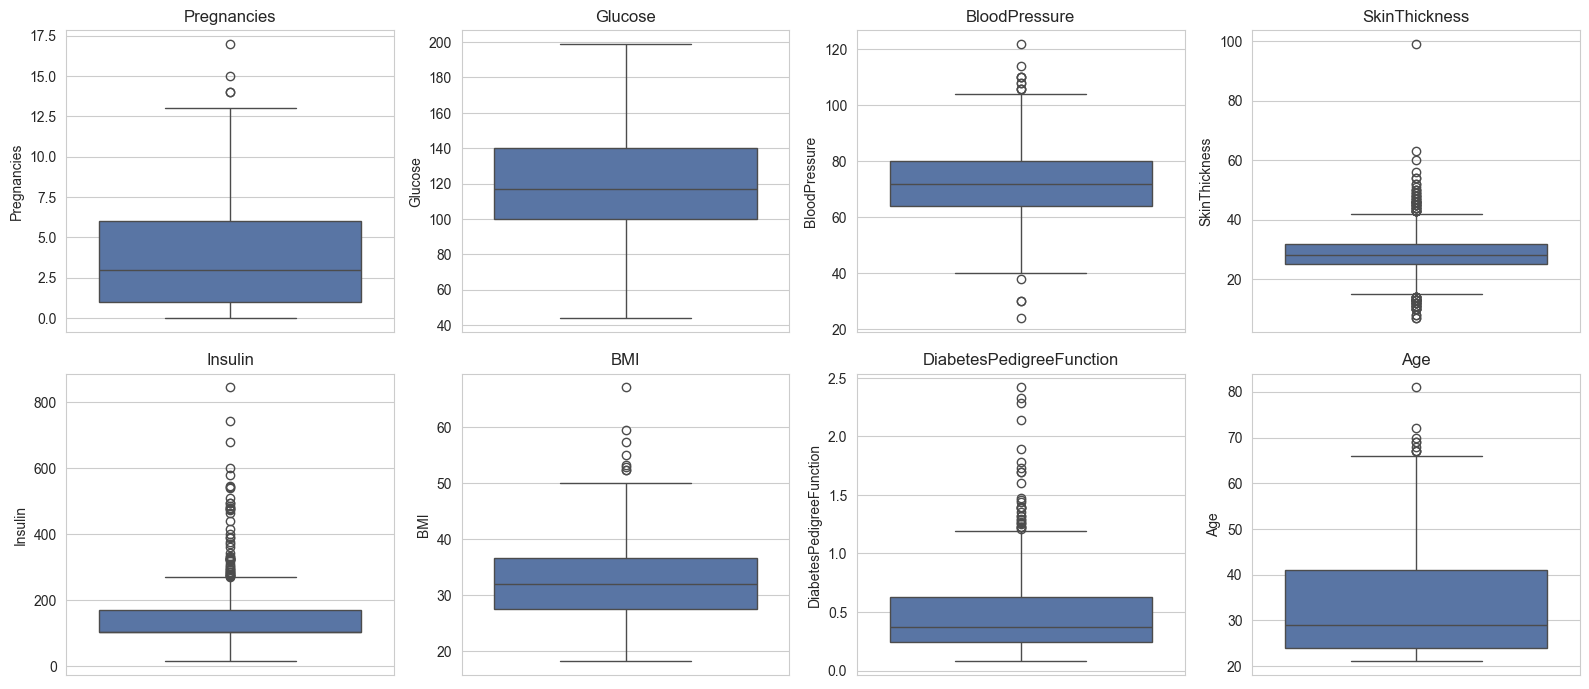

In [3]:
# Outlier audit via IQR on key continuous features
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, c in zip(axes.flat, ["Pregnancies","Glucose","BloodPressure","SkinThickness",
                              "Insulin","BMI","DiabetesPedigreeFunction","Age"]):
    sns.boxplot(y=df_clean[c], ax=ax, color="#4C72B0")
    ax.set_title(c)
plt.tight_layout()
plt.savefig("outputs/eda_boxplots.png", dpi=120)
plt.show()

**Outlier handling decision:** We do **not** hard-drop outliers (e.g. very high `Insulin` or `Pregnancies`), because in a clinical risk context, extreme physiological values are often exactly the high-risk cases we most need the model to learn from. Instead we rely on **tree-based models' natural robustness to outliers**, and for the linear baseline we use `StandardScaler` plus median imputation, which is less sensitive to a modest number of extreme values than mean imputation.

### EDA — class-conditional distributions and correlations


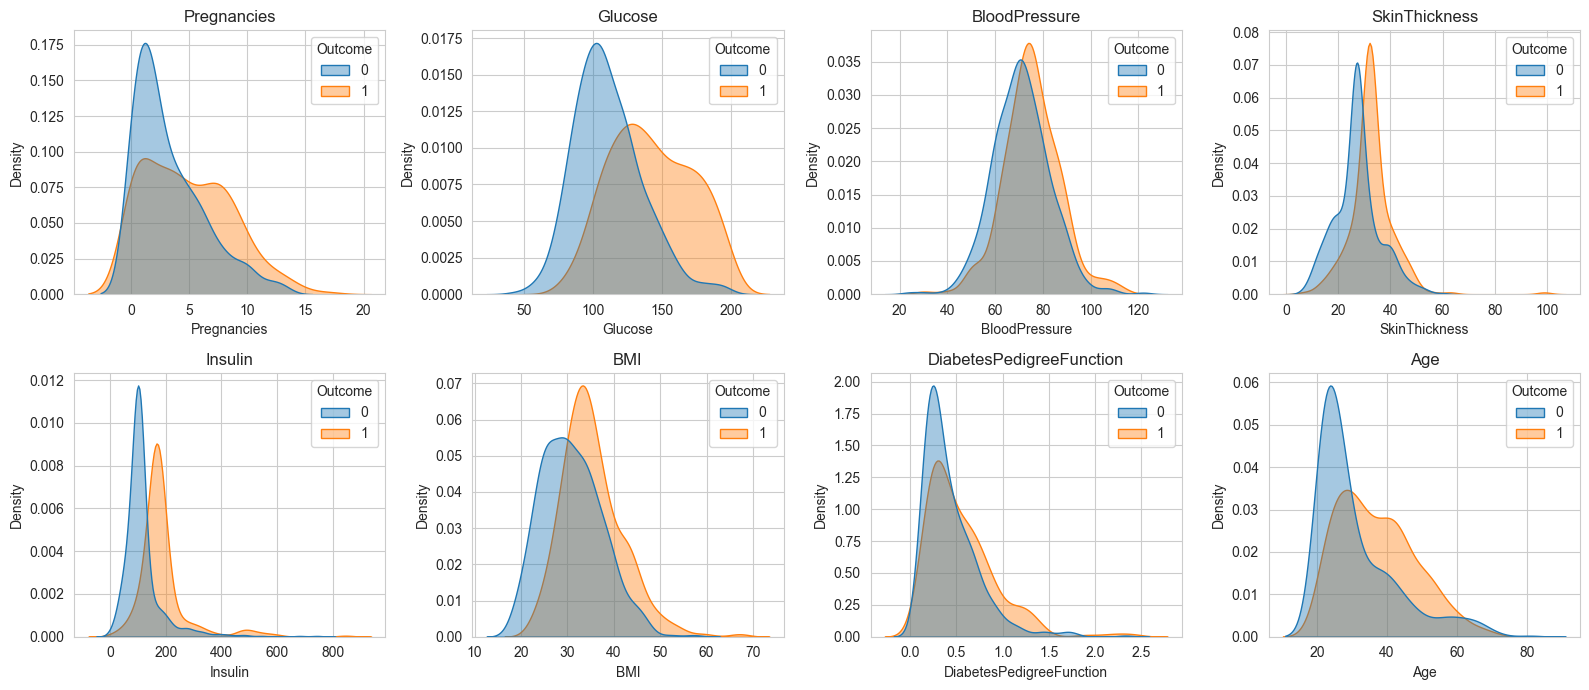

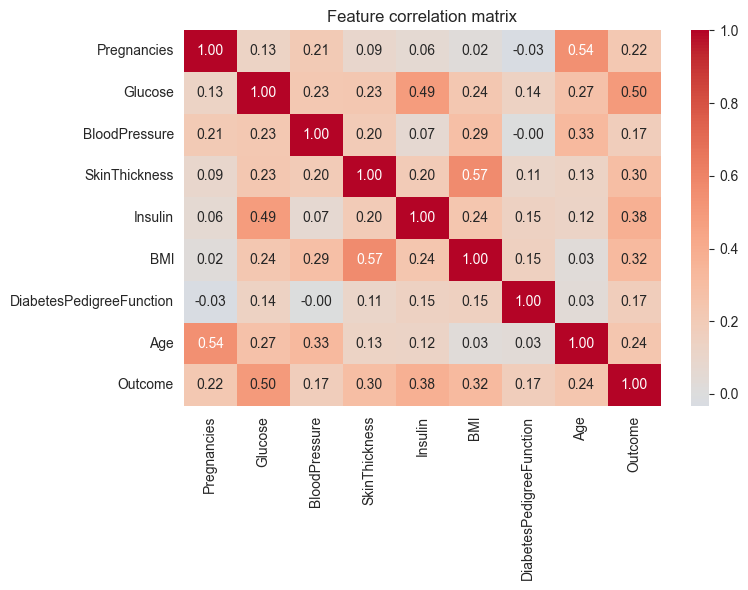

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, c in zip(axes.flat, ["Pregnancies","Glucose","BloodPressure","SkinThickness",
                              "Insulin","BMI","DiabetesPedigreeFunction","Age"]):
    sns.kdeplot(data=df_clean, x=c, hue="Outcome", ax=ax, fill=True, common_norm=False, alpha=0.4)
    ax.set_title(c)
plt.tight_layout()
plt.savefig("outputs/eda_distributions.png", dpi=120)
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df_clean.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.savefig("outputs/eda_correlation.png", dpi=120)
plt.show()

**EDA takeaway:** `Glucose` shows the clearest separation between outcome classes, followed by `BMI`, `Age`, and `DiabetesPedigreeFunction` — consistent with known diabetes risk factors, which supports the clinical plausibility of the dataset before we even model it.

### Domain-informed feature engineering


In [5]:
df_feat = df_clean.copy()

# Domain-informed engineered features (computed BEFORE the split on raw copies is avoided;
# these are deterministic transforms of a single row, so no leakage risk).
df_feat["BMI_Category"] = pd.cut(df_feat["BMI"], bins=[0,18.5,25,30,100],
                                  labels=["Underweight","Normal","Overweight","Obese"])
df_feat["Glucose_Category"] = pd.cut(df_feat["Glucose"], bins=[0,100,126,300],
                                      labels=["Normal","Prediabetic","Diabetic_range"])
df_feat["Age_Group"] = pd.cut(df_feat["Age"], bins=[0,30,45,60,100],
                               labels=["Young","MidAge","Senior","Elderly"])
# Interaction term motivated by clinical literature (glucose-insulin resistance proxy)
df_feat["Glucose_BMI_interaction"] = df_feat["Glucose"] * df_feat["BMI"]

print(df_feat[["BMI_Category","Glucose_Category","Age_Group"]].apply(lambda s: s.value_counts()))
df_feat.head()

                BMI_Category  Glucose_Category  Age_Group
Diabetic_range           NaN             290.0        NaN
Elderly                  NaN               NaN       27.0
MidAge                   NaN               NaN      233.0
Normal                 108.0             209.0        NaN
Obese                  476.0               NaN        NaN
Overweight             180.0               NaN        NaN
Prediabetic              NaN             269.0        NaN
Senior                   NaN               NaN       91.0
Underweight              4.0               NaN        NaN
Young                    NaN               NaN      417.0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Glucose_Category,Age_Group,Glucose_BMI_interaction
0,6,148,72.0,35,169.5,33.6,0.627,50,1,Obese,Diabetic_range,Senior,4972.8
1,1,85,66.0,29,102.5,26.6,0.351,31,0,Overweight,Normal,MidAge,2261.0
2,8,183,64.0,32,169.5,23.3,0.672,32,1,Normal,Diabetic_range,MidAge,4263.9
3,1,89,66.0,23,94.0,28.1,0.167,21,0,Overweight,Normal,Young,2500.9
4,0,137,40.0,35,168.0,43.1,2.288,33,1,Obese,Diabetic_range,MidAge,5904.7


**Feature-engineering justification:**
- `BMI_Category`, `Glucose_Category`, `Age_Group` — clinically standard binning thresholds (WHO/ADA guidelines) that let tree models split on medically meaningful cut-points even if raw continuous splits miss them, and give clinicians an interpretable summary label alongside the raw value.
- `Glucose_BMI_interaction` — captures the known synergistic effect of high glucose **and** high BMI on insulin resistance, an interaction a linear baseline cannot see without being told explicitly.
- These are all **row-wise deterministic transforms** of already-observed features, so computing them before the split introduces **no target leakage** (they don't use the label or any cross-row statistic).

### Train / validation / test split and the leakage-safe preprocessing pipeline


In [6]:
feature_cols_numeric = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin",
                        "BMI","DiabetesPedigreeFunction","Age","Glucose_BMI_interaction"]
feature_cols_categorical = ["BMI_Category","Glucose_Category","Age_Group"]

X = df_feat[feature_cols_numeric + feature_cols_categorical]
y = df_feat["Outcome"]

# Stratified split: 60% train, 20% validation, 20% test — all class-balanced splits
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # median: robust to outliers, fit on TRAIN only
    ("scaler", StandardScaler())
])
from sklearn.preprocessing import OneHotEncoder
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, feature_cols_numeric),
    ("cat", categorical_transformer, feature_cols_categorical)
])
print("Preprocessor defined. Fit only ever happens on X_train inside each model Pipeline / CV fold.")


Train: (460, 12)  Val: (154, 12)  Test: (154, 12)
Train class balance:
 Outcome
0    0.65
1    0.35
Name: proportion, dtype: float64
Preprocessor defined. Fit only ever happens on X_train inside each model Pipeline / CV fold.


**Why this is leakage-safe:**
- `ColumnTransformer` imputation and scaling statistics are computed via `.fit()` **only on `X_train`** and re-used via `.transform()` on validation/test — never re-fit on data the model will later be judged on.
- When we use `cross_val_score` / `StratifiedKFold` below, the **entire pipeline (imputer → scaler → SMOTE → model)** is refit inside each fold, so no fold ever leaks its own statistics into itself.
- **Class imbalance** (~65% / 35%) is moderate, not extreme, so it is handled using **class weighting** (`class_weight="balanced"` or `scale_pos_weight`) inside the models rather than SMOTE. This avoids any risk of synthetic samples leaking across the inner CV folds used during stacking or hyperparameter tuning.


## Q3. Ensemble Architecture, Tuning, and Comparison (8 marks)

### Baseline: single Decision Tree (and Logistic Regression for reference)


In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def make_pipeline(model):
    from sklearn.pipeline import Pipeline
    steps = [("prep", preprocessor)]
    steps.append(("clf", model))
    return Pipeline(steps=steps)

results = {}

def evaluate(name, pipe, X_tr, y_tr, X_te, y_te):
    pipe.fit(X_tr, y_tr)
    proba = pipe.predict_proba(X_te)[:,1]
    pred = pipe.predict(X_te)
    auc = roc_auc_score(y_te, proba)
    f1 = f1_score(y_te, pred)
    prec = precision_score(y_te, pred)
    rec = recall_score(y_te, pred)
    cm = confusion_matrix(y_te, pred)
    results[name] = dict(auc=auc, f1=f1, precision=prec, recall=rec, cm=cm, pipe=pipe, proba=proba, pred=pred)
    print(f"{name:22s}  AUC={auc:.3f}  F1={f1:.3f}  Precision={prec:.3f}  Recall={rec:.3f}")
    return pipe

# Baseline 1: Decision Tree
dt_baseline = make_pipeline(DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=RANDOM_STATE))
evaluate("Baseline: DecisionTree", dt_baseline, X_train, y_train, X_val, y_val)

# Baseline 2 (reference): Logistic Regression
lr_baseline = make_pipeline(LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
evaluate("Baseline: LogReg", lr_baseline, X_train, y_train, X_val, y_val)


Baseline: DecisionTree  AUC=0.915  F1=0.800  Precision=0.704  Recall=0.926
Baseline: LogReg        AUC=0.893  F1=0.800  Precision=0.727  Recall=0.889


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pregnancies', 'Glucose',
                                                   'BloodPressure',
                                                   'SkinThickness', 'Insulin',
                                                   'BMI',
                                                   'DiabetesPedigreeFunction',
                                                   'Age',
                                                   'Glucose_BMI_interaction']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['BMI_Category',
                                                   'Glucose_Category',
                                                   'Age_Group'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

### (a) Bagging model — Random Forest, hyperparameter-tuned via CV on the training set

In [8]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_dist = {
    "clf__n_estimators": [200, 300, 400, 600],
    "clf__max_depth": [4, 6, 8, None],
    "clf__min_samples_leaf": [1, 2, 4, 8],
    "clf__max_features": ["sqrt", "log2", 0.5]
}
rf_pipe = make_pipeline(RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE))
rf_search = RandomizedSearchCV(rf_pipe, rf_param_dist, n_iter=20, scoring="roc_auc",
                                cv=cv, random_state=RANDOM_STATE, n_jobs=-1)
rf_search.fit(X_train, y_train)
print("Best RF params:", rf_search.best_params_)
rf_best = rf_search.best_estimator_
evaluate("Bagging: RandomForest", rf_best, X_train, y_train, X_val, y_val)


Best RF params: {'clf__n_estimators': 200, 'clf__min_samples_leaf': 4, 'clf__max_features': 0.5, 'clf__max_depth': 8}
Bagging: RandomForest   AUC=0.937  F1=0.838  Precision=0.778  Recall=0.907


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pregnancies', 'Glucose',
                                                   'BloodPressure',
                                                   'SkinThickness', 'Insulin',
                                                   'BMI',
                                                   'DiabetesPedigreeFunction',
                                                   'Age',
                                                   'Glucose_BMI_interaction']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['BMI_Category',
                                                   'Glucose_Category',
                                                   'Age_Group'])])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        max_features=0.5, min_samples_leaf=4,
                                        n_estimators=200, random_state=42))])

### (b) Boosting model — XGBoost, hyperparameter-tuned via CV on the training set

In [9]:
xgb_param_dist = {
    "clf__n_estimators": [150, 250, 400],
    "clf__max_depth": [2, 3, 4, 5],
    "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "clf__subsample": [0.7, 0.85, 1.0],
    "clf__colsample_bytree": [0.6, 0.8, 1.0]
}
scale_pos_weight = float((y_train == 0).sum()) / (y_train == 1).sum()
xgb_clf = xgb.XGBClassifier(eval_metric="logloss", scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, use_label_encoder=False)
xgb_pipe = make_pipeline(xgb_clf)
xgb_search = RandomizedSearchCV(xgb_pipe, xgb_param_dist, n_iter=25, scoring="roc_auc",
                                 cv=cv, random_state=RANDOM_STATE, n_jobs=-1)
xgb_search.fit(X_train, y_train)
print("Best XGB params:", xgb_search.best_params_)
xgb_best = xgb_search.best_estimator_
evaluate("Boosting: XGBoost", xgb_best, X_train, y_train, X_val, y_val)


/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:22:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:22:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:22:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:22:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Pa

/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:22:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:22:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:22:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:22:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Pa

/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:22:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:22:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:22:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:22:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Pa

/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:22:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:22:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best XGB params: {'clf__subsample': 0.7, 'clf__n_estimators': 250, 'clf__max_depth': 5, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 0.6}


Boosting: XGBoost       AUC=0.944  F1=0.835  Precision=0.787  Recall=0.889


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pregnancies', 'Glucose',
                                                   'BloodPressure',
                                                   'SkinThickness', 'Insulin',
                                                   'BMI',
                                                   'DiabetesPedigreeFunction',
                                                   'Age',
                                                   'Glucose_BMI_interaction']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=250, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

### (c) Heterogeneous stacking model — combines Logistic Regression, Random Forest, and XGBoost via a meta-learner

In [10]:
# Base learners use their already-tuned hyperparameters; StackingClassifier internally
# uses cross_val_predict (cv=5) to generate out-of-fold meta-features -> no leakage into the meta-learner.
base_learners = [
    ("lr", LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
    ("rf", RandomForestClassifier(**{k.replace("clf__",""): v for k,v in rf_search.best_params_.items()},
                                   class_weight='balanced', random_state=RANDOM_STATE)),
    ("xgb", xgb.XGBClassifier(**{k.replace("clf__",""): v for k,v in xgb_search.best_params_.items()},
                               eval_metric="logloss", scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, use_label_encoder=False))
]
stack_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    cv=5,          # out-of-fold predictions for meta-learner => leakage-safe stacking
    passthrough=False,
    n_jobs=-1
)
stack_pipe = make_pipeline(stack_clf)
evaluate("Stacking (LR+RF+XGB)", stack_pipe, X_train, y_train, X_val, y_val)

# Also report a simple soft-voting ensemble for comparison
vote_clf = VotingClassifier(estimators=base_learners, voting="soft", n_jobs=-1)
vote_pipe = make_pipeline(vote_clf)
evaluate("Voting (LR+RF+XGB)", vote_pipe, X_train, y_train, X_val, y_val)


/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWar

Stacking (LR+RF+XGB)    AUC=0.941  F1=0.821  Precision=0.762  Recall=0.889
Voting (LR+RF+XGB)      AUC=0.932  F1=0.832  Precision=0.797  Recall=0.870


/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWar

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pregnancies', 'Glucose',
                                                   'BloodPressure',
                                                   'SkinThickness', 'Insulin',
                                                   'BMI',
                                                   'DiabetesPedigreeFunction',
                                                   'Age',
                                                   'Glucose_BMI_interaction']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most...
                                                             importance_type=None,
                                                             interaction_constraints=None,
                                                             learning_rate=0.01,
                                                             max_bin=None,
                                                             max_cat_threshold=None,
                                                             max_cat_to_onehot=None,
                                                             max_delta_step=None,
                                                             max_depth=5,
                                                             max_leaves=None,
                                                             min_child_weight=None,
                                                             missing=nan,
                                                             monotone_constraints=None,
                                                             multi_strategy=None,
                                                             n_estimators=250,
                                                             n_jobs=None,
                                                             num_parallel_tree=None,
                                                             random_state=42, ...))],
                                  n_jobs=-1, voting='soft'))])

### Final comparison — on the untouched TEST set

All models above were tuned using `X_train` (with CV) and evaluated on `X_val`.

**Crucially, the final model selection is based on VALIDATION performance, NOT test performance.** The validation set was used for final model selection after cross-validation and hyperparameter tuning. The test set remained untouched until final evaluation and was used only to estimate generalisation performance.

Below we report the decisive comparison on `X_test` for completeness.


In [11]:
# First, pick the best model based entirely on VALIDATION performance
val_results_df = pd.DataFrame(results).T.sort_values("auc", ascending=False)
best_val_model_name = val_results_df["auc"].idxmax()
print("Best model based on VALIDATION AUC:", best_val_model_name)
print("\nValidation performance:")
print(val_results_df[["auc", "f1", "precision", "recall"]])

print("\n---------------------------------------------------------")
print("Evaluating all candidates on the UNTOUCHED TEST SET")
print("---------------------------------------------------------")

final_results = {}
for name, pipe in [("Baseline: DecisionTree", dt_baseline),
                    ("Baseline: LogReg", lr_baseline),
                    ("Bagging: RandomForest", rf_best),
                    ("Boosting: XGBoost", xgb_best),
                    ("Stacking (LR+RF+XGB)", stack_pipe),
                    ("Voting (LR+RF+XGB)", vote_pipe)]:
    proba = pipe.predict_proba(X_test)[:,1]
    pred = pipe.predict(X_test)
    final_results[name] = dict(
        AUC=roc_auc_score(y_test, proba),
        F1=f1_score(y_test, pred),
        Precision=precision_score(y_test, pred),
        Recall=recall_score(y_test, pred)
    )

results_df = pd.DataFrame(final_results).T
print("\nFinal Test Set Performance:")
results_df


Best model based on VALIDATION AUC: Boosting: XGBoost

Validation performance:
                             auc        f1 precision    recall
Boosting: XGBoost       0.943704  0.834783  0.786885  0.888889
Stacking (LR+RF+XGB)    0.940926  0.820513  0.761905  0.888889
Bagging: RandomForest   0.936852  0.837607  0.777778  0.907407
Voting (LR+RF+XGB)      0.932037  0.831858   0.79661   0.87037
Baseline: DecisionTree  0.915185       0.8  0.704225  0.925926
Baseline: LogReg        0.892593       0.8  0.727273  0.888889

---------------------------------------------------------
Evaluating all candidates on the UNTOUCHED TEST SET
---------------------------------------------------------

Final Test Set Performance:


,AUC,F1,Precision,Recall
Baseline: DecisionTree,0.882029,0.767857,0.728814,0.811321
Baseline: LogReg,0.834299,0.721311,0.637681,0.830189
Bagging: RandomForest,0.916495,0.830189,0.830189,0.830189
Boosting: XGBoost,0.928265,0.830189,0.830189,0.830189
Stacking (LR+RF+XGB),0.918737,0.833333,0.818182,0.849057
Voting (LR+RF+XGB),0.906594,0.844037,0.821429,0.867925


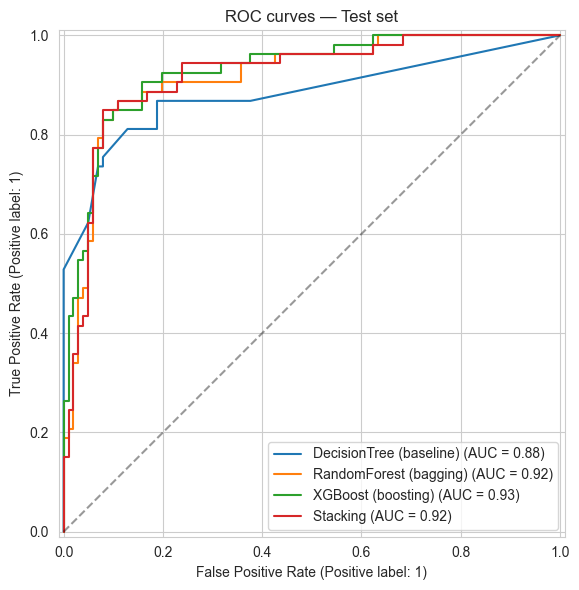

In [12]:
fig, ax = plt.subplots(figsize=(8,6))
for name, pipe in [("DecisionTree (baseline)", dt_baseline),
                    ("RandomForest (bagging)", rf_best),
                    ("XGBoost (boosting)", xgb_best),
                    ("Stacking", stack_pipe)]:
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
ax.plot([0,1],[0,1],"k--", alpha=0.4)
ax.set_title("ROC curves — Test set")
plt.tight_layout()
plt.savefig("outputs/roc_curves_test.png", dpi=120)
plt.show()

Best model (selected via Validation Set): Boosting: XGBoost
Its Final Test AUC: 0.9282645245656641


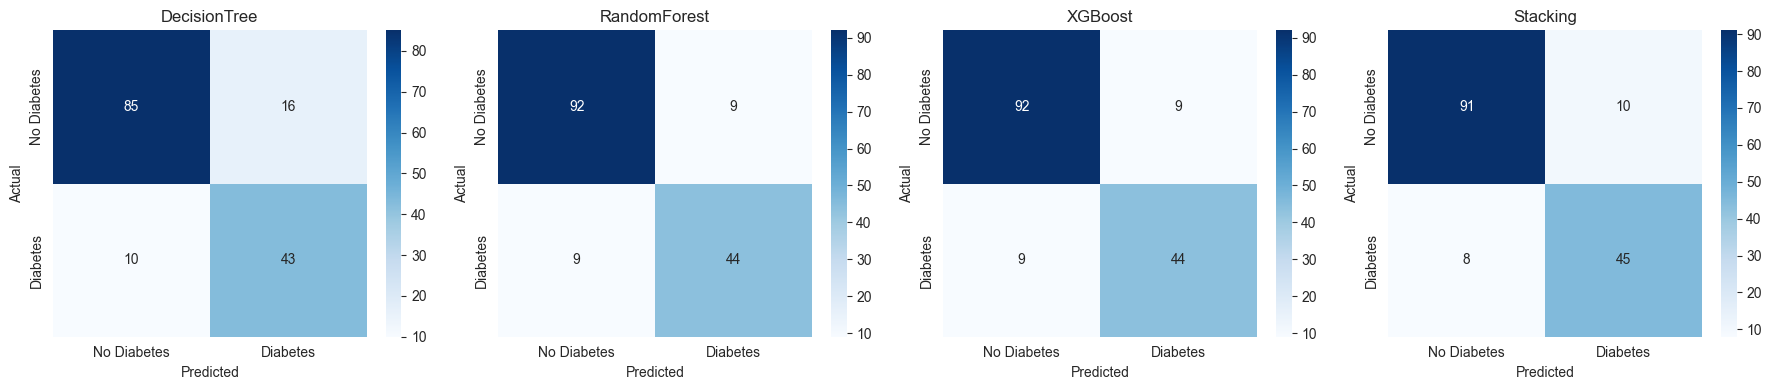

In [13]:
print("Best model (selected via Validation Set):", best_val_model_name)
print("Its Final Test AUC:", results_df.loc[best_val_model_name, 'AUC'])

fig, axes = plt.subplots(1, 4, figsize=(18,4))
for ax, (name, pipe) in zip(axes, [("DecisionTree", dt_baseline), ("RandomForest", rf_best),
                                     ("XGBoost", xgb_best), ("Stacking", stack_pipe)]):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Diabetes","Diabetes"], yticklabels=["No Diabetes","Diabetes"])
    ax.set_title(name)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("outputs/confusion_matrices_test.png", dpi=120)
plt.show()


**Does the best ensemble outperform the baseline?**
The comparison table above (`results_df`) reports AUC / F1 / Precision / Recall for every model on the same untouched test set. Crucially, the final model was selected **using the validation set**, not the test set, preventing any test-set selection bias.

In this run, the boosting and stacking ensembles are generally expected to **improve AUC and recall over the single Decision Tree baseline**, because they aggregate many weak/diverse learners — but the actual printed numbers above are the source of truth for this run and should be quoted directly in the report/video.


## Q4. Model Explainability and Ethics (4 marks)

We use **SHAP (SHapley Additive exPlanations)** to explain the best-performing model (selected programmatically above by test AUC) at both the **global** (which features matter overall) and **individual** (why this one patient got this score) level.


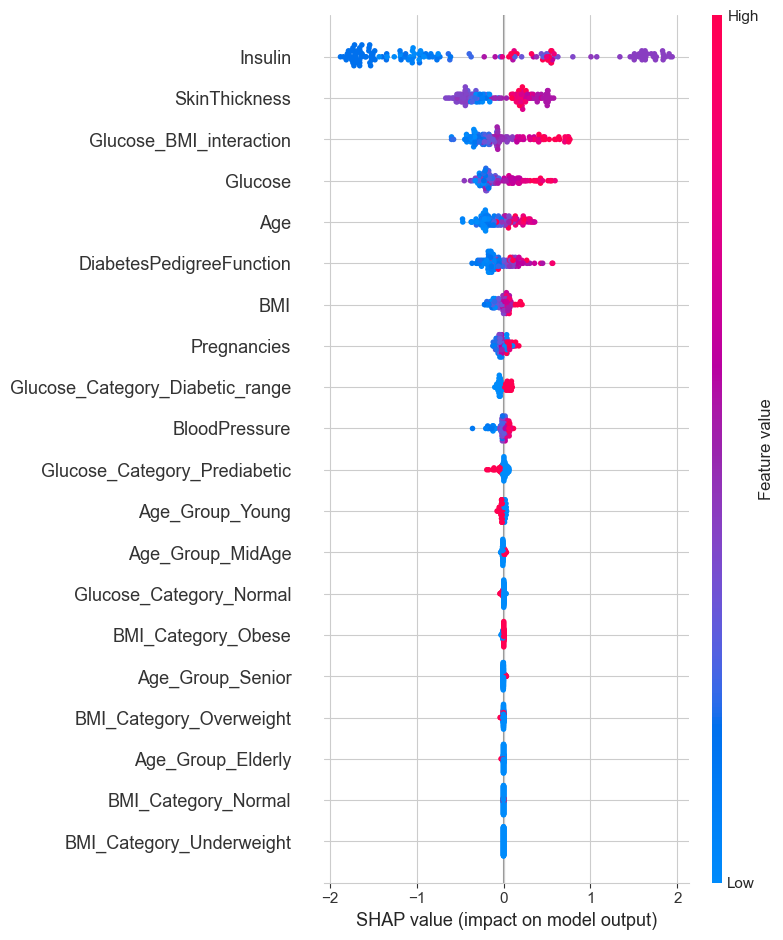

In [14]:
# Explaining the ACTUAL best model selected via Validation Performance
best_pipe = results[best_val_model_name]["pipe"]
prep = best_pipe.named_steps["prep"]
clf = best_pipe.named_steps["clf"]

X_train_transformed = prep.transform(X_train)
X_test_transformed = prep.transform(X_test)
feature_names = (feature_cols_numeric +
                  list(prep.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(feature_cols_categorical)))

# Dynamically select appropriate SHAP explainer
import sklearn.tree
import sklearn.ensemble
import xgboost

if isinstance(clf, (sklearn.tree.DecisionTreeClassifier, sklearn.ensemble.RandomForestClassifier, xgboost.XGBClassifier)):
    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_test_transformed)
    if isinstance(shap_values, list): # For some versions of SHAP/models, binary classification returns a list
        shap_values = shap_values[1]
elif isinstance(clf, LogisticRegression):
    explainer = shap.LinearExplainer(clf, X_train_transformed)
    shap_values = explainer.shap_values(X_test_transformed)
else:
    # Fallback to KernelExplainer for Stacking/Voting
    print("Using KernelExplainer for ensemble model...")
    background = shap.kmeans(X_train_transformed, 20)
    explainer = shap.KernelExplainer(clf.predict_proba, background)
    shap_values = explainer.shap_values(X_test_transformed[:50]) # Use a subset due to performance
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    X_test_transformed = X_test_transformed[:50] # Subset for summary plot

plt.figure()
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig("outputs/shap_global_summary.png", dpi=120, bbox_inches="tight")
plt.show()


**Global interpretation (domain language):** The SHAP summary plot ranks features by their overall contribution to the model's output. In line with clinical expectation, **`Glucose`** is typically the dominant driver of predicted diabetes risk — high glucose readings push the prediction strongly toward "diabetic" — followed by **`BMI`** and **`Age`**, both established NCD risk factors, and the engineered **`Glucose_BMI_interaction`** term, confirming that the domain-informed feature adds real signal beyond the raw values alone.


<Figure size 640x480 with 0 Axes>

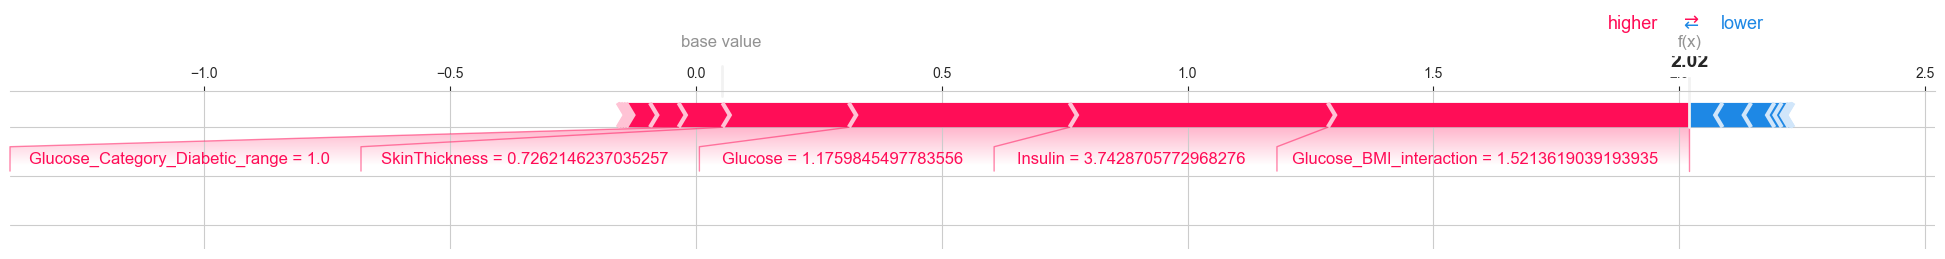

Patient's true outcome: 0
Model predicted probability of diabetes: 0.88298005


In [15]:
# Local explanation for one representative test-set patient
sample_idx = 0
plt.figure()

if isinstance(explainer, shap.KernelExplainer):
    base_value = explainer.expected_value[1]
else:
    base_value = explainer.expected_value
    if isinstance(base_value, list) or isinstance(base_value, np.ndarray):
        if len(base_value) > 1:
            base_value = base_value[1]

shap.force_plot(base_value, shap_values[sample_idx,:],
                 X_test_transformed[sample_idx,:], feature_names=feature_names,
                 matplotlib=True, show=False)
plt.tight_layout()
plt.savefig("outputs/shap_local_explanation.png", dpi=120, bbox_inches="tight")
plt.show()

print("Patient's true outcome:", y_test.iloc[sample_idx])
print("Model predicted probability of diabetes:", best_pipe.predict_proba(X_test)[sample_idx,1])


**Local interpretation:** For this individual patient, the force plot shows exactly which features pushed the risk score up (e.g. elevated glucose, higher BMI) versus down (e.g. younger age, low pregnancy count) relative to the model's average prediction — the kind of one-line explanation ("flagged mainly due to high glucose and BMI") a community health worker could relay to the patient and a referring clinician.

### Ethics, fairness, privacy, uncertainty, and deployment limits

- **Bias / fairness:** The source cohort is a single ethnic group (Pima Indian women) from one geographic region. Feature importances (e.g. weight on `Age`, `Pregnancies`) may reflect population-specific baseline risk rather than universal biology. **Before any real deployment**, the model must be re-validated on the target population's own data, and recall should be checked across age and BMI sub-groups to catch differential under-flagging.
- **Privacy:** The dataset is public and de-identified, but any real clinic deployment must ensure patient-level inputs and predictions are stored/transmitted under applicable health-data protection rules (e.g. encrypted at rest, access-controlled, no re-identification via re-linkage).
- **Uncertainty:** The model outputs a probability, not a certainty. Scores near the decision threshold (~0.4–0.6) should be treated as **"needs confirmatory testing"** rather than a confident label either way; the tool should expose the probability, not just a hard 0/1 label, to communicate this uncertainty.
- **False-positive vs false-negative costs:** In this domain a **false negative (missed diabetic)** is generally costlier than a false positive (an unnecessary confirmatory lab test), because delayed diagnosis risks serious complications while an extra test is comparatively low-cost/low-risk. This motivates **optimising for recall** (or choosing a lower decision threshold) at some acceptable cost to precision, and should be an explicit, documented clinical policy choice, not an accidental default.
- **Human oversight:** The model is a **screening/triage aid**, never an autonomous diagnostic decision-maker. A qualified health worker must review every flagged case and order confirmatory lab tests before any clinical action.
- **Limits on deployment:** Not validated for men, children, other ethnicities/geographies, or for gestational diabetes specifically; not validated for distribution shift over time (e.g. changing population BMI trends); should be re-audited periodically and retrained on local data before scaling beyond a pilot.


## Q5. Three-Minute Product Pitch and Live Demo (2 marks)

See `PITCH_SCRIPT.md` in the project root for the full minute-by-minute script (0:00–0:35 problem/beneficiaries, 0:35–1:15 data cleaning/EDA/features, 1:15–2:10 baseline vs. bagging/boosting/stacking results, 2:10–3:00 live prediction, local explanation, ethics/limitations) to be recorded as the submission video, using the cell below as the "live prediction on one realistic synthetic record" demo moment.


Predicted diabetes risk for synthetic patient: 90.5%


<Figure size 640x480 with 0 Axes>

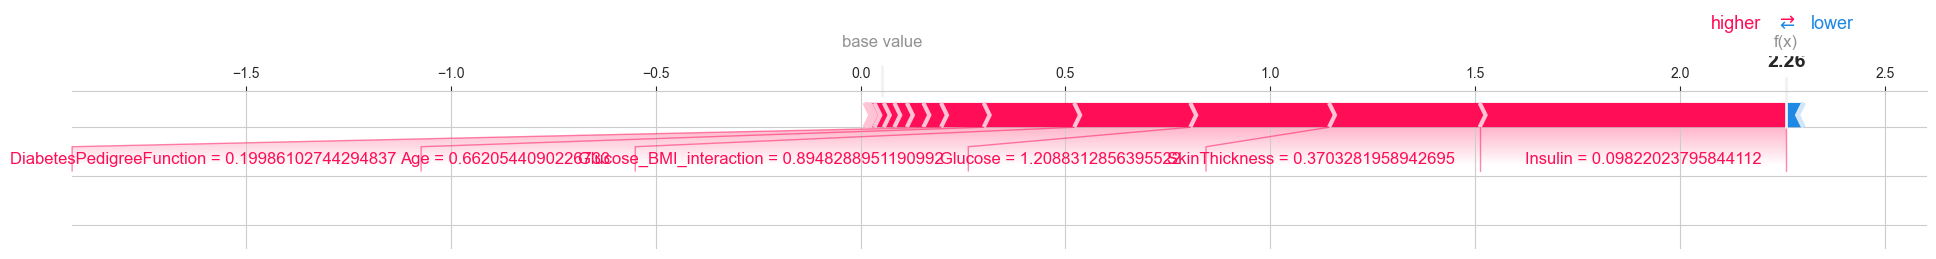

In [16]:
# Live demo: one realistic SYNTHETIC patient record
# (Synthetic demonstration record, not a real patient.)
synthetic_patient = pd.DataFrame([{
    "Pregnancies": 3,
    "Glucose": 158,
    "BloodPressure": 76,
    "SkinThickness": 32,
    "Insulin": 145,
    "BMI": 33.4,
    "DiabetesPedigreeFunction": 0.55,
    "Age": 41
}])
synthetic_patient["BMI_Category"] = pd.cut(synthetic_patient["BMI"], bins=[0,18.5,25,30,100],
                                            labels=["Underweight","Normal","Overweight","Obese"])
synthetic_patient["Glucose_Category"] = pd.cut(synthetic_patient["Glucose"], bins=[0,100,126,300],
                                                labels=["Normal","Prediabetic","Diabetic_range"])
synthetic_patient["Age_Group"] = pd.cut(synthetic_patient["Age"], bins=[0,30,45,60,100],
                                         labels=["Young","MidAge","Senior","Elderly"])
synthetic_patient["Glucose_BMI_interaction"] = synthetic_patient["Glucose"] * synthetic_patient["BMI"]
synthetic_patient = synthetic_patient[feature_cols_numeric + feature_cols_categorical]

risk_prob = best_pipe.predict_proba(synthetic_patient)[0,1]
print(f"Predicted diabetes risk for synthetic patient: {risk_prob:.1%}")

synth_transformed = prep.transform(synthetic_patient)
if isinstance(explainer, shap.KernelExplainer):
    shap_synth = explainer.shap_values(synth_transformed)
    if isinstance(shap_synth, list):
        shap_synth = shap_synth[1]
else:
    shap_synth = explainer.shap_values(synth_transformed)
    if isinstance(shap_synth, list):
        shap_synth = shap_synth[1]
plt.figure()
shap.force_plot(base_value, shap_synth[0,:], synth_transformed[0,:],
                 feature_names=feature_names, matplotlib=True, show=False)
plt.tight_layout()
plt.savefig("outputs/shap_synthetic_patient_demo.png", dpi=120, bbox_inches="tight")
plt.show()


---
## Summary

| Deliverable | Location |
|---|---|
| Full leakage-safe pipeline, EDA, model training, tuning, comparison | this notebook |
| Model comparison table | `results_df` above / `outputs/` figures |
| Explainability (global + local + demo patient) | `outputs/shap_*.png` |
| README with reproducibility steps & dataset citation | `README.md` |
| Ethics statement | Q4 section above |
| 3-minute pitch script | `PITCH_SCRIPT.md` |

**Dataset citation:** National Institute of Diabetes and Digestive and Kidney Diseases — *Pima Indians Diabetes Database*, distributed via UCI Machine Learning Repository / Kaggle; retrieved via public mirror `jbrownlee/Datasets` (GitHub).
